# Patient Health Risk Prediction
### Emergency Health Record App: ML Model Training & Comparison

This notebook:
1. Generates synthetic patient data mirroring the Supabase schema
2. Trains 5 different ML models
3. Compares them 

---
## 0. Install & Import Dependencies

In [19]:
# Install missing libraries 
#!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful')

All imports successful


---
## 1. Generate Synthetic Data

Each row = one patient. 

Columns come directly from:
- `patient_profiles` → age, sex, blood_type
- `lifestyle_factors` → smoking, alcohol, drugs, socioeconomic_class ...
- `medical_conditions` → count of chronic / acute conditions
- `medications` → count
- `allergies` → count
- `surgeries` / `hospitalizations` → count
- `vaccinations` → covid vaccinated flag

In [3]:
N = 1000  # number of synthetic patients

df = pd.DataFrame({

    # patient_profiles 
    'age': np.random.randint(18, 90, N),
    'sex': np.random.choice(['male', 'female'], N),
    'blood_type': np.random.choice(
        ['A+', 'B+', 'O+', 'AB+', 'A-', 'B-', 'O-', 'AB-', None],
        N, p=[0.14, 0.10, 0.38, 0.04, 0.06, 0.02, 0.07, 0.02, 0.17]
    ),

    # lifestyle_factors 
    'smoking':           np.random.choice([True, False], N, p=[0.30, 0.70]),
    'packs_per_day':     np.round(np.random.uniform(0, 2.5, N), 2),
    'smoking_years':     np.round(np.random.uniform(0, 40, N), 1),
    'chicha':            np.random.choice([True, False], N, p=[0.20, 0.80]),
    'chicha_years':      np.round(np.random.uniform(0, 20, N), 1),
    'drugs':             np.random.choice([True, False], N, p=[0.10, 0.90]),
    'alcohol_frequency': np.random.choice(
        ['never', 'rarely', 'monthly', 'weekly', 'daily'],
        N, p=[0.40, 0.25, 0.15, 0.13, 0.07]
    ),
    'socioeconomic_class': np.random.choice(
        ['low', 'middle', 'high', 'unknown'],
        N, p=[0.30, 0.45, 0.15, 0.10]
    ),
    'lives_alone':       np.random.choice([True, False], N, p=[0.25, 0.75]),
    'has_caregiver':     np.random.choice([True, False], N, p=[0.20, 0.80]),
    'work_status':       np.random.choice(
        ['employed', 'unemployed', 'retired', 'student'],
        N, p=[0.50, 0.15, 0.25, 0.10]
    ),

    # medical_conditions: counts per patient
    'chronic_conditions_count': np.random.randint(0, 6, N),
    'acute_conditions_count':   np.random.randint(0, 4, N),

    # medications 
    'medications_count': np.random.randint(0, 10, N),

    # allergies 
    'allergies_count':   np.random.randint(0, 5, N),

    # surgeries / hospitalizations 
    'surgeries_count':         np.random.randint(0, 4, N),
    'hospitalizations_count':  np.random.randint(0, 5, N),

    # vaccinations 
    'is_covid_vaccinated':     np.random.choice([True, False], N, p=[0.60, 0.40]),
})

# Zero out packs_per_day / smoking_years / chicha_years
df.loc[~df['smoking'], 'packs_per_day'] = 0.0
df.loc[~df['smoking'], 'smoking_years'] = 0.0
df.loc[~df['chicha'],  'chicha_years']  = 0.0

print(f' Generated {N} synthetic patients')
df.head()

 Generated 1000 synthetic patients


,age,sex,blood_type,smoking,packs_per_day,smoking_years,chicha,chicha_years,drugs,alcohol_frequency,...,lives_alone,has_caregiver,work_status,chronic_conditions_count,acute_conditions_count,medications_count,allergies_count,surgeries_count,hospitalizations_count,is_covid_vaccinated
0,69,male,O+,False,0.00,0.0,False,0.0,False,never,...,True,False,retired,1,0,5,2,1,0,True
1,32,male,O+,False,0.00,0.0,False,0.0,False,rarely,...,True,False,retired,5,1,1,2,1,4,False
2,89,female,A-,True,1.93,19.0,False,0.0,False,never,...,False,False,unemployed,4,2,2,1,0,4,True
3,78,male,A+,False,0.00,0.0,True,2.1,False,never,...,True,False,employed,2,2,4,0,1,2,True
4,38,male,AB+,False,0.00,0.0,False,0.0,False,never,...,False,False,retired,4,3,3,1,2,4,False


***Demographics***: 
- age (uniform 18–90)
- sex (50% male/female)
- blood_type .

***Lifestyle***: 
- smoking (30% prevalence)
- chicha (20%)
- drugs (10%)
- alcohol_frequency (categorized from never to daily)
- work_status (employed, unemployed, retired, or student).

***Clinical History***: 
- Counts for chronic and acute conditions
- active medications
- allergies
- past surgeries
- emergency hospitalizations.

***Vaccinations***: is_covid_vaccinated flag (60% prevalence).

***Sanity Rules***: Corrects inconsistencies by forcing consumption fields (packs_per_day, smoking_years, chicha_years) to 0.0 for non-smokers and non-chicha users.

---
## 2. Create Risk Labels
Simulate a clinically inspired weighted risk score, then bucket into **low / medium / high**.

Class distribution:
risk_level
medium    627
low       216
high      157
Name: count, dtype: int64


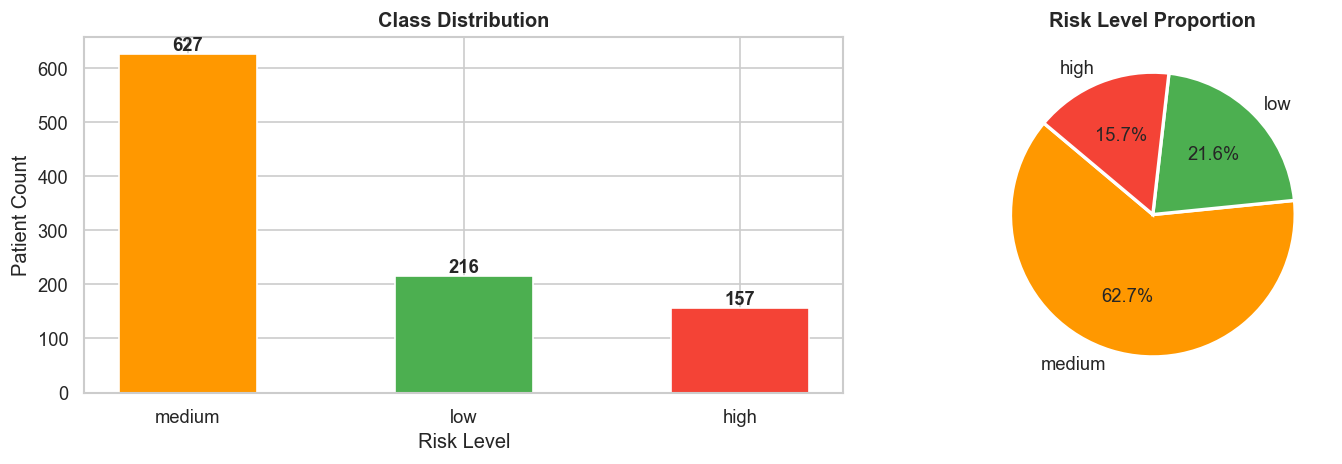

Risk labels created


In [4]:
# Weighted risk scoring
risk_raw = (
    (df['age'] > 60).astype(int)                        * 20 +
    (df['age'].between(45, 60)).astype(int)              * 10 +
    df['smoking'].astype(int)                            * 25 +
    (df['packs_per_day'] > 1).astype(int)               *  5 +
    df['chicha'].astype(int)                             * 10 +
    df['drugs'].astype(int)                              * 15 +
    (df['alcohol_frequency'] == 'daily').astype(int)    * 15 +
    (df['alcohol_frequency'] == 'weekly').astype(int)   *  8 +
    (df['chronic_conditions_count'] > 2).astype(int)    * 20 +
    (df['chronic_conditions_count'] == 1).astype(int)   * 10 +
    (df['medications_count'] > 4).astype(int)           * 15 +
    (df['hospitalizations_count'] > 2).astype(int)      * 10 +
    (df['surgeries_count'] > 1).astype(int)             *  5 +
    (df['socioeconomic_class'] == 'low').astype(int)    *  5 +
    df['lives_alone'].astype(int)                        *  3 +
    (~df['is_covid_vaccinated']).astype(int)             *  5 +
    np.random.randint(0, 15, N)  # realistic noise
)

# Normalize 0-1
df['risk_score'] = (risk_raw / risk_raw.max()).round(4)

# Bucket into 3 classes
df['risk_level'] = pd.cut(
    df['risk_score'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['low', 'medium', 'high'],
    right=False
)
df['risk_level'] = df['risk_level'].astype(str)

print('Class distribution:')
print(df['risk_level'].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = {'low': '#4CAF50', 'medium': '#FF9800', 'high': '#F44336'}
counts = df['risk_level'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[colors[l] for l in counts.index], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Patient Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            colors=[colors[l] for l in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Risk Level Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Risk labels created')

- ***The Dominance of Medium Risk (62.7%)***: This mimics real-world outpatient cohorts. The vast majority of individuals in any general medical database have mild-to-moderate risk profiles, for instance, middle-aged adults with one or two minor risk factors (casual drinking or occasional smoking) but no severe underlying acute diseases or recurring hospitalizations.

- ***The Low-Risk Cohort (21.6%)***: Represents young, active, non-smoking individuals who have zero chronic conditions and are fully vaccinated. They require minimal emergency services.

- ***The Critical High-Risk Cohort (15.7%)***: Represents the top-tier emergency group. These are elderly patients, heavy smokers with multiple chronic diseases, high medication counts, recurring hospitalizations, and unvaccinated statuses.

---
## 3. Feature Engineering & Preprocessing

In [5]:
df_encoded = df.copy()

# Encode sex
df_encoded['sex_encoded'] = (df_encoded['sex'] == 'male').astype(int)

# Encode alcohol_frequency 
alcohol_map = {'never': 0, 'rarely': 1, 'monthly': 2, 'weekly': 3, 'daily': 4}
df_encoded['alcohol_encoded'] = df_encoded['alcohol_frequency'].map(alcohol_map).fillna(0)

# Encode socioeconomic_class 
socio_map = {'low': 0, 'middle': 1, 'high': 2, 'unknown': 1}
df_encoded['socio_encoded'] = df_encoded['socioeconomic_class'].map(socio_map).fillna(1)

# Encode work_status
work_map = {'employed': 3, 'student': 2, 'retired': 1, 'unemployed': 0}
df_encoded['work_encoded'] = df_encoded['work_status'].map(work_map).fillna(1)

# Final feature list: MUST match exactly what Flutter sends to the API
FEATURES = [
    'age',
    'sex_encoded',
    'smoking',
    'packs_per_day',
    'smoking_years',
    'chicha',
    'chicha_years',
    'drugs',
    'alcohol_encoded',
    'socio_encoded',
    'work_encoded',
    'lives_alone',
    'has_caregiver',
    'chronic_conditions_count',
    'acute_conditions_count',
    'medications_count',
    'allergies_count',
    'surgeries_count',
    'hospitalizations_count',
    'is_covid_vaccinated',
]

X = df_encoded[FEATURES].astype(float)
y = df_encoded['risk_level']

# Train / test split: stratified so every class is represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'Features   : {len(FEATURES)}')
print('\nTrain class split:')
print(y_train.value_counts())

Train size : 800
Test size  : 200
Features   : 20

Train class split:
risk_level
medium    502
low       173
high      125
Name: count, dtype: int64


---
## 4. Train 5 Models

In [6]:
# Define all models
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1,
        max_depth=5, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150, learning_rate=0.1,
        max_depth=5, random_state=RANDOM_STATE,
        eval_metric='mlogloss', verbosity=0
    ),
}

# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Train all models + collect metrics
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')

    if name == 'XGBoost':
        model.fit(X_train, y_train_enc)
        y_pred_enc = model.predict(X_test)
        y_pred     = le.inverse_transform(y_pred_enc)
        cv_scores  = cross_val_score(model, X, le.transform(y), cv=cv, scoring='accuracy')
    else:
        model.fit(X_train, y_train)
        y_pred    = model.predict(X_test)
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    acc       = accuracy_score(y_test, y_pred)
    f1_macro  = f1_score(y_test, y_pred, average='macro',     zero_division=0)
    f1_weight = f1_score(y_test, y_pred, average='weighted',  zero_division=0)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)

    results[name] = {
        'model':       model,
        'y_pred':      y_pred,
        'accuracy':    round(acc, 4),
        'f1_macro':    round(f1_macro, 4),
        'f1_weighted': round(f1_weight, 4),
        'precision':   round(precision, 4),
        'recall':      round(recall, 4),
        'cv_mean':     round(cv_scores.mean(), 4),
        'cv_std':      round(cv_scores.std(),  4),
    }
    print(f'Accuracy={acc:.3f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f} ')

print('\n All models trained')

Training Logistic Regression... Accuracy=0.750  CV=0.799±0.009 
Training Decision Tree... Accuracy=0.770  CV=0.709±0.015 
Training Random Forest... Accuracy=0.795  CV=0.809±0.009 
Training Gradient Boosting... Accuracy=0.805  CV=0.802±0.020 
Training XGBoost... Accuracy=0.810  CV=0.809±0.015 

 All models trained


---
## 5. Visual Comparisons

In [7]:
# Build a summary DataFrame
metrics_df = pd.DataFrame([
    {
        'Model':       name,
        'Accuracy':    r['accuracy'],
        'F1 Macro':    r['f1_macro'],
        'F1 Weighted': r['f1_weighted'],
        'Precision':   r['precision'],
        'Recall':      r['recall'],
        'CV Mean':     r['cv_mean'],
        'CV Std':      r['cv_std'],
    }
    for name, r in results.items()
]).set_index('Model').sort_values('Accuracy', ascending=False)

print('=== Model Comparison Table ===')
print(metrics_df.to_string())

=== Model Comparison Table ===
                     Accuracy  F1 Macro  F1 Weighted  Precision  Recall  CV Mean  CV Std
Model                                                                                   
XGBoost                 0.810    0.7562       0.8029     0.8117   0.810    0.809  0.0146
Gradient Boosting       0.805    0.7554       0.7988     0.8057   0.805    0.802  0.0201
Random Forest           0.795    0.7246       0.7825     0.8046   0.795    0.809  0.0092
Decision Tree           0.770    0.7167       0.7654     0.7671   0.770    0.709  0.0150
Logistic Regression     0.750    0.7003       0.7468     0.7464   0.750    0.799  0.0086


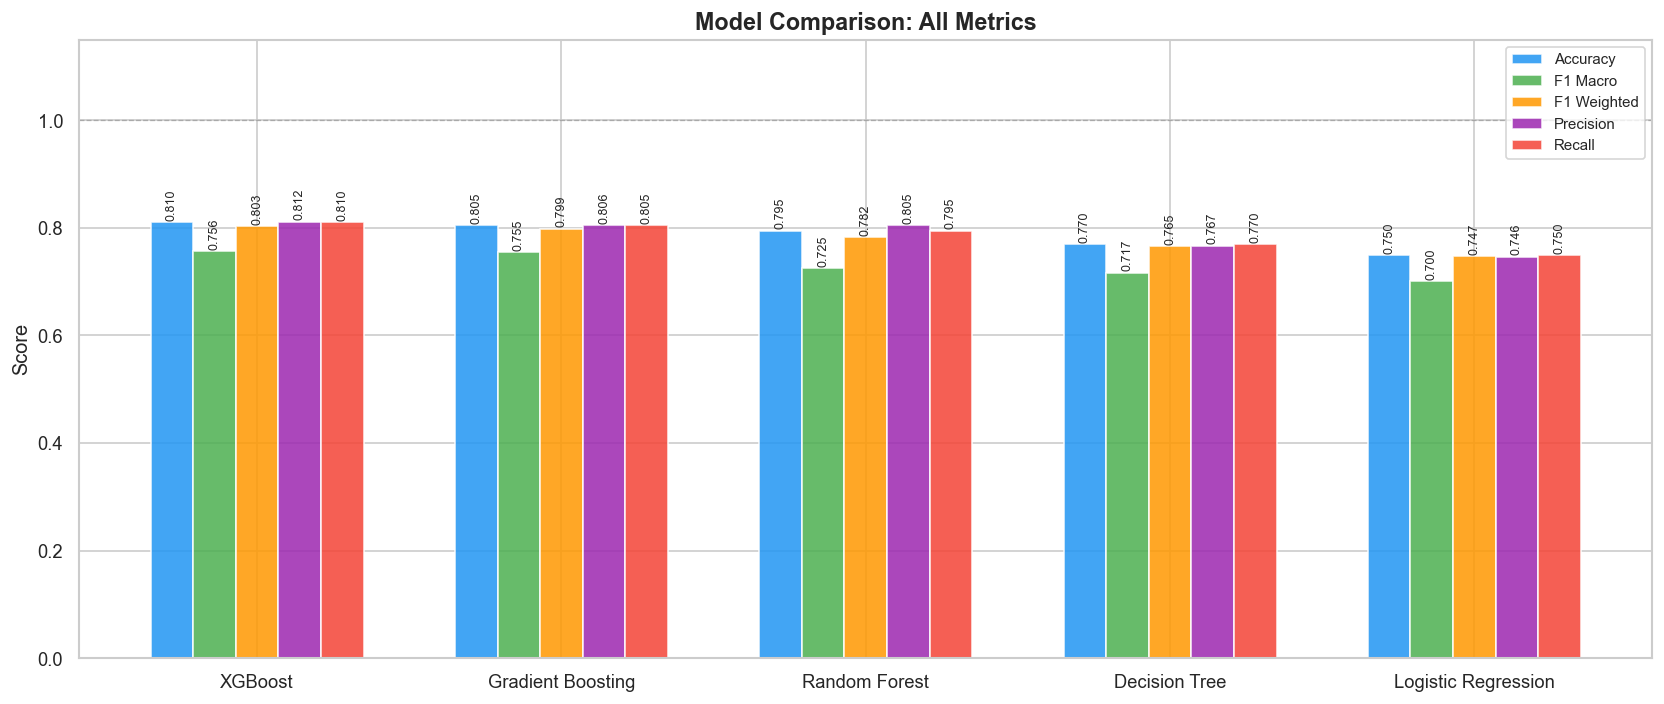

In [8]:
# Grouped bar 
metric_cols   = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall']
model_names   = metrics_df.index.tolist()
x             = np.arange(len(model_names))
bar_width     = 0.14
palette       = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metric_cols, palette)):
    vals = metrics_df[metric].values
    offset = (i - len(metric_cols)/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('02_all_metrics_comparison.png', bbox_inches='tight')
plt.show()

This chart visually repeats the comparison table.

It shows that XGBoost and Gradient Boosting are very close across most metrics. XGBoost is slightly higher in accuracy, precision, weighted F1, and macro F1. However, this chart **does not focus specifically on high-risk recall**.

So this chart supports XGBoost as the best general ML model.

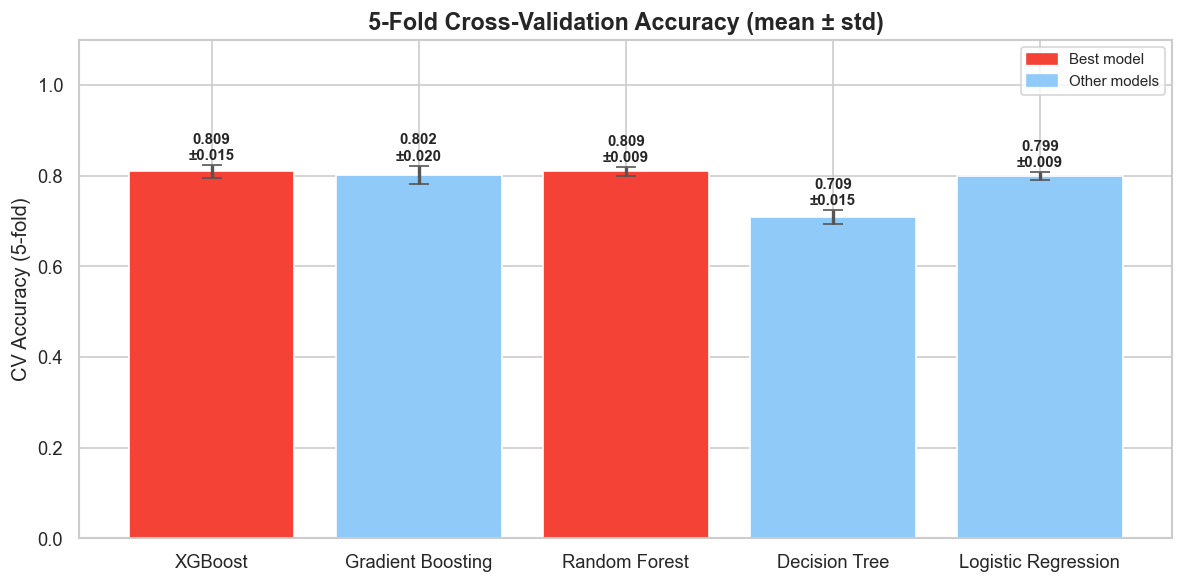

In [9]:
# Cross-validation mean ± std
cv_means = metrics_df['CV Mean'].values
cv_stds  = metrics_df['CV Std'].values
colors_cv = ['#F44336' if m == cv_means.max() else '#90CAF9' for m in cv_means]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(model_names, cv_means, color=colors_cv,
              yerr=cv_stds, capsize=6, edgecolor='white',
              error_kw={'elinewidth': 2, 'ecolor': '#555'})

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.005,
            f'{mean:.3f}\n±{std:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.10)
ax.set_ylabel('CV Accuracy (5-fold)', fontsize=12)
ax.set_title('5-Fold Cross-Validation Accuracy (mean ± std)', fontsize=14, fontweight='bold')

best_patch = mpatches.Patch(color='#F44336', label='Best model')
other_patch = mpatches.Patch(color='#90CAF9', label='Other models')
ax.legend(handles=[best_patch, other_patch], fontsize=9)

plt.tight_layout()
plt.savefig('03_cv_comparison.png', bbox_inches='tight')
plt.show()

The cross-validation graph shows model stability across 5 folds.

- `XGBoost`: 0.809 ± 0.015
- `Random Forest`: 0.809 ± 0.009
- `Gradient Boosting`: 0.802 ± 0.020
- `Logistic Regression`: 0.799 ± 0.009
- `Decision Tree`: 0.709 ± 0.015

→ Random Forest is the most stable because it has the smallest standard deviation among the top models. XGBoost has the same CV mean but slightly more variation.

Possible contradiction: the chart marks both XGBoost and Random Forest in red as “best model” because they tie for highest CV mean. But this only means best cross-validation accuracy, not best final clinical model.

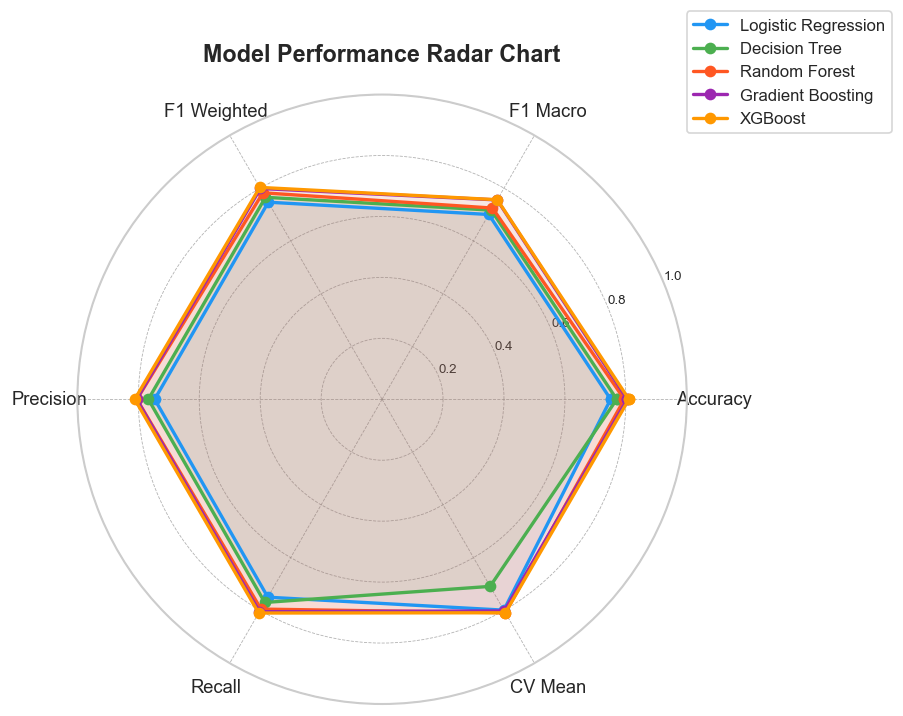

In [12]:
# Radar / spider chart
metric_cols_radar = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall', 'CV Mean']
num_metrics = len(metric_cols_radar)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

radar_colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (name, r), color in zip(results.items(), radar_colors):
    vals = [metrics_df.loc[name, m] for m in metric_cols_radar]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_cols_radar, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.set_title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('04_radar_chart.png', bbox_inches='tight')
plt.show()

this chart supports XGBoost as the strongest general-purpose model, but it still does not emphasize high-risk recall enough for clinical triage.

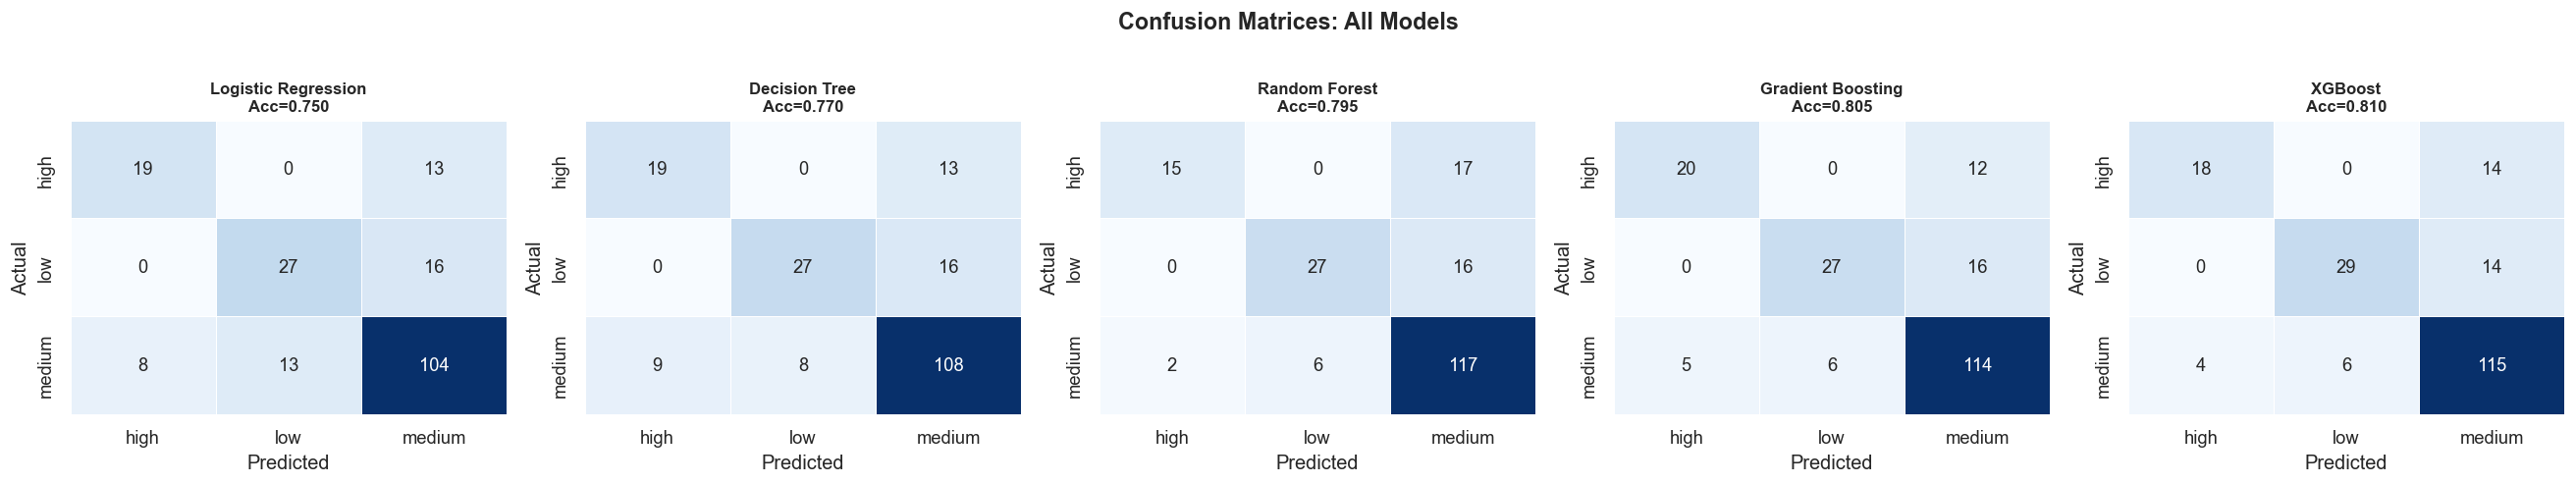

In [13]:
# Confusion matrices for all 5 models 
classes = ['high', 'low', 'medium']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'], labels=classes)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=classes, yticklabels=classes,
        cbar=False
    )
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', bbox_inches='tight')
plt.show()


| Model                 | Correct High-Risk | Missed High-Risk | High-Risk Recall |
|-----------------------|-------------------|------------------|------------------|
| Logistic Regression   | 19/32             | 13               | 59.4%            |
| Decision Tree         | 19/32             | 13               | 59.4%            |
| Random Forest         | 15/32             | 17               | 46.9%            |
| Gradient Boosting     | 20/32             | 12               | 62.5%            |
| XGBoost               | 18/32             | 14               | 56.3%            |

Although XGBoost had the highest overall accuracy, Gradient Boosting is the best at catching high-risk patients.

A composite score is not suited for a medical application because it weights all classes equally, the same applies for F1_Weighted that rewards a model proportionally to class size, which in turn misclassifies a high risk patient as medium. That is a false negative for the most critical class, which is clinically dangerous.

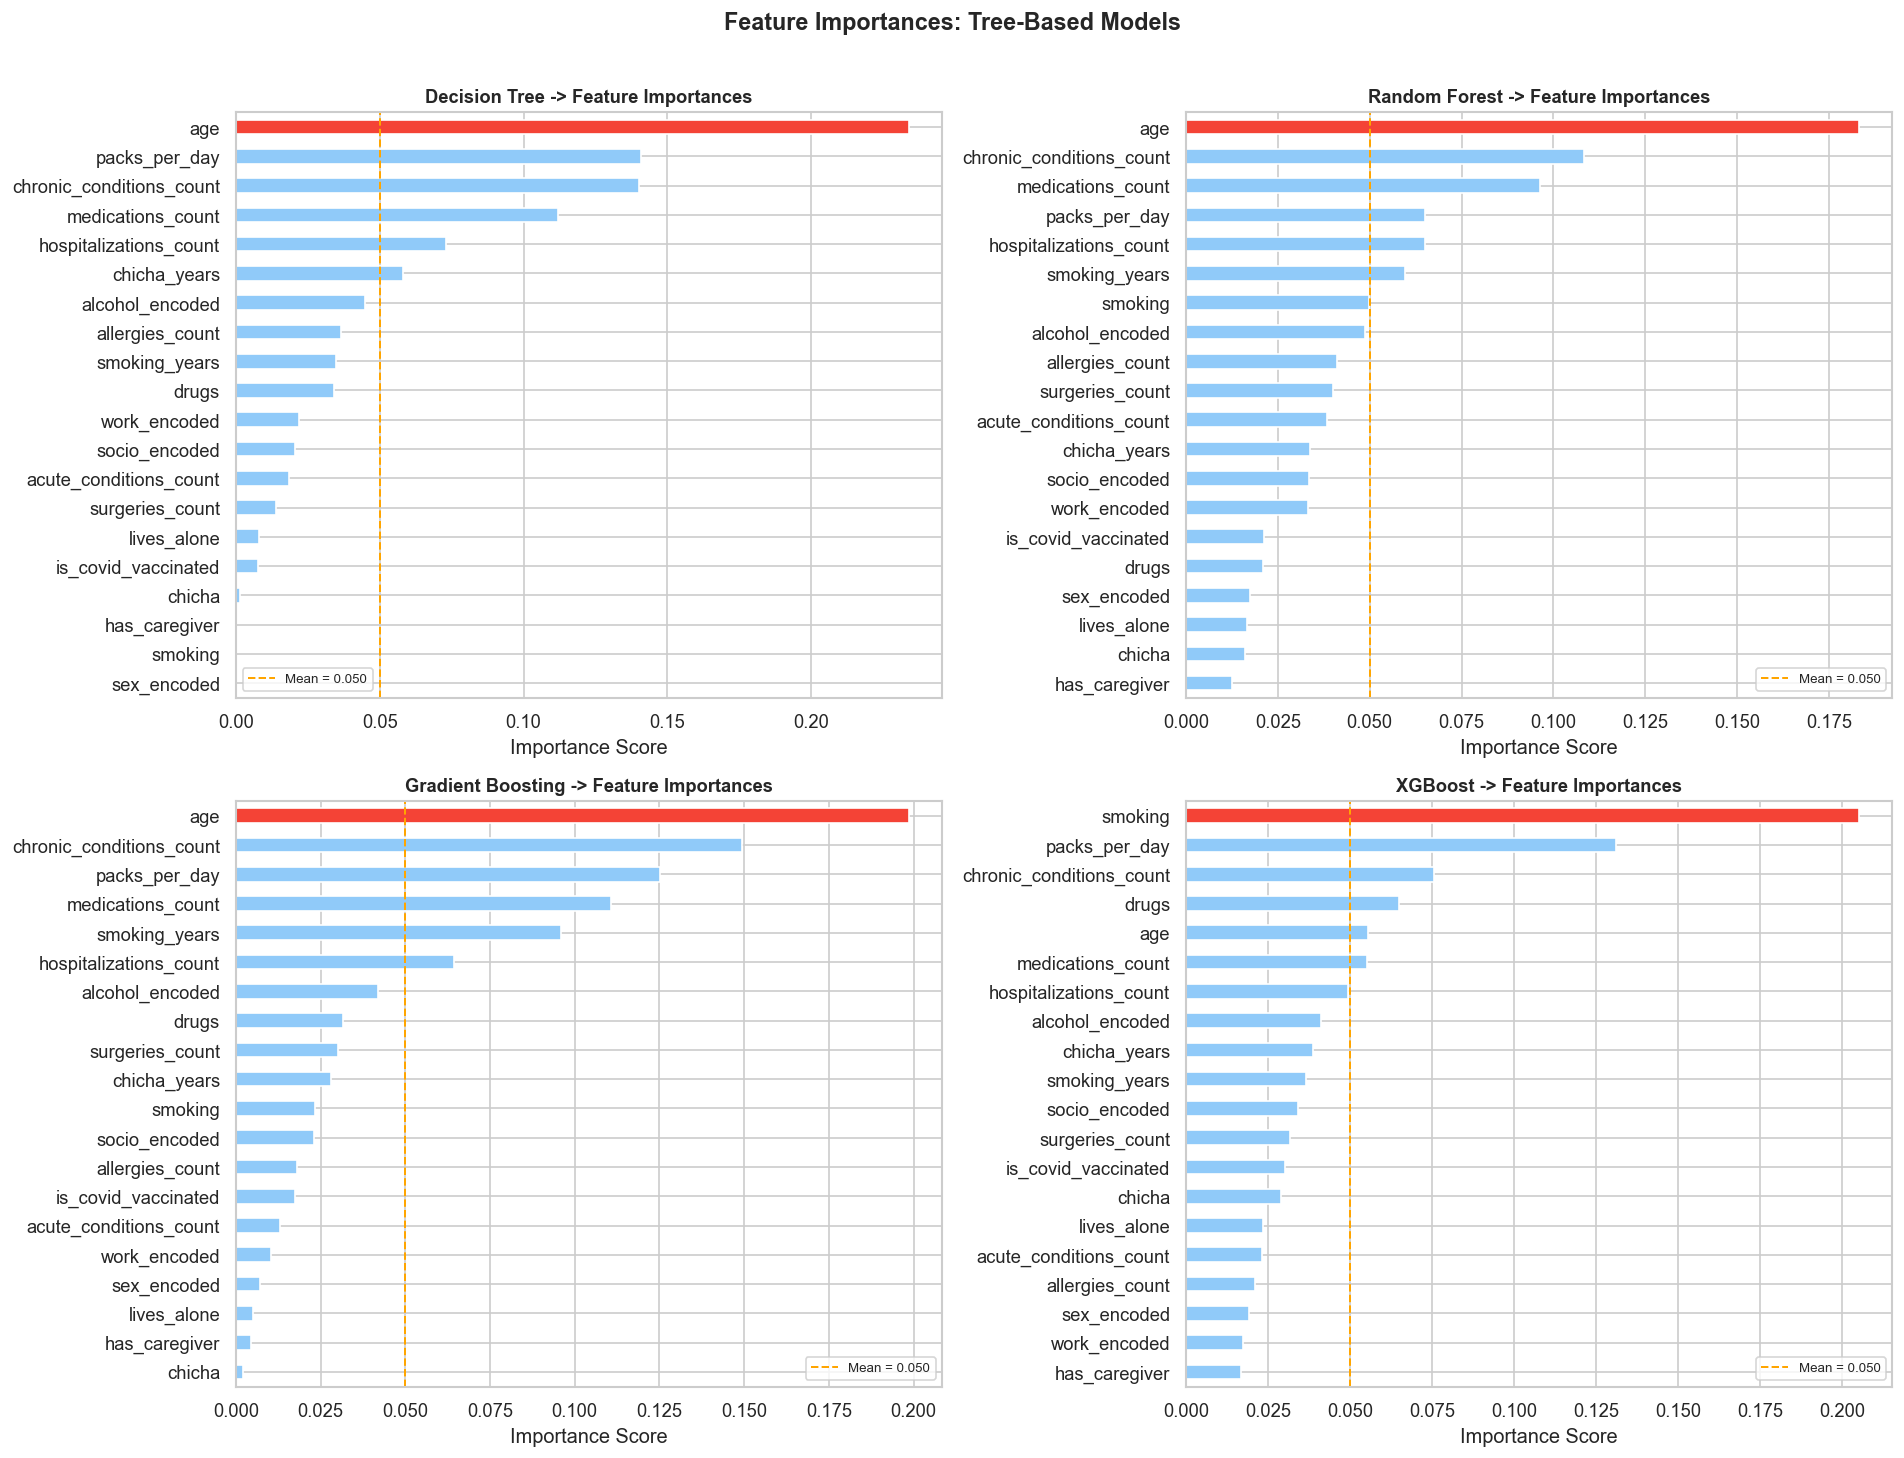

In [14]:
# Feature importances for tree-based models
tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, name in zip(axes, tree_models):
    model   = results[name]['model']
    imp     = model.feature_importances_
    feat_imp = pd.Series(imp, index=FEATURES).sort_values(ascending=True)

    colors_bar = ['#F44336' if v == feat_imp.max() else '#90CAF9' for v in feat_imp.values]

    feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(f'{name} -> Feature Importances', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.axvline(x=feat_imp.mean(), color='orange', linestyle='--',
               linewidth=1.2, label=f'Mean = {feat_imp.mean():.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Feature Importances: Tree-Based Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_feature_importances.png', bbox_inches='tight')
plt.show()

The feature-importance plots show which variables the tree-based models use most.

Common important features include:

- age
- smoking
- packs_per_day
- chronic_conditions_count
- medications_count
- hospitalizations_count

the models are learning clinically reasonable patterns. All these factures strongly influence risk.

There is a small difference between models: Gradient Boosting emphasizes age, while XGBoost emphasizes smoking. 

→ This is not a contradiction. Different tree algorithms measure feature importance differently.

---
## 6. Picking the Best Model 

In [15]:
# Clinically-weighted model selection

# Use a custom composite that rewards HIGH-RISK recall heavily, then overall balance (F1-macro), then stability (CV mean).

# Weights:
#   50%  →  High-risk recall  (did we catch the dangerous patients?)
#   25%  →  F1 Macro          (balanced across all 3 classes, not size-weighted)
#   25%  →  CV Mean           (generalisation / stability)

def high_risk_recall(y_true, y_pred):
    """Recall specifically for the 'high' class."""
    cm = confusion_matrix(y_true, y_pred, labels=['high', 'low', 'medium'])
    tp = cm[0, 0]          # true positives for 'high'
    fn = cm[0, 1] + cm[0, 2]  # high patients called low or medium
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

clinical_rows = []

for name, r in results.items():
    hr_recall  = high_risk_recall(y_test, r['y_pred'])
    f1_mac     = r['f1_macro']
    cv_mean    = r['cv_mean']
    
    # Clinically-weighted composite
    clinical_score = (
        hr_recall * 0.50 +
        f1_mac    * 0.25 +
        cv_mean   * 0.25
    )
    
    clinical_rows.append({
        'Model':              name,
        'High-Risk Recall':   round(hr_recall,      4),
        'F1 Macro':           round(f1_mac,          4),
        'CV Mean':            round(cv_mean,         4),
        'Clinical Score':     round(clinical_score,  4),
        'Test Accuracy':      r['accuracy'],           # shown for context
    })

clinical_df = (
    pd.DataFrame(clinical_rows)
      .set_index('Model')
      .sort_values('Clinical Score', ascending=False)
)

print('=== Clinically-Weighted Model Ranking ===')
print('Weights: 50% High-Risk Recall | 25% F1-Macro | 25% CV Mean\n')
print(clinical_df.to_string())

best_name  = clinical_df['Clinical Score'].idxmax()
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print('\n' + '=' * 55)
print(f'  BEST MODEL (clinical): {best_name}')
print('=' * 55)
print(f"  High-Risk Recall : {clinical_df.loc[best_name, 'High-Risk Recall']:.1%}  ← most important")
print(f"  F1 Macro         : {clinical_df.loc[best_name, 'F1 Macro']}")
print(f"  CV Mean          : {clinical_df.loc[best_name, 'CV Mean']}")
print(f"  Clinical Score   : {clinical_df.loc[best_name, 'Clinical Score']}")
print('=' * 55)
print()
print('Full Classification Report:')
print(classification_report(y_test, best_pred, zero_division=0))

=== Clinically-Weighted Model Ranking ===
Weights: 50% High-Risk Recall | 25% F1-Macro | 25% CV Mean

                     High-Risk Recall  F1 Macro  CV Mean  Clinical Score  Test Accuracy
Model                                                                                  
Gradient Boosting              0.6250    0.7554    0.802          0.7018          0.805
XGBoost                        0.5625    0.7562    0.809          0.6726          0.810
Logistic Regression            0.5938    0.7003    0.799          0.6717          0.750
Decision Tree                  0.5938    0.7167    0.709          0.6533          0.770
Random Forest                  0.4688    0.7246    0.809          0.6178          0.795

  BEST MODEL (clinical): Gradient Boosting
  High-Risk Recall : 62.5%  ← most important
  F1 Macro         : 0.7554
  CV Mean          : 0.802
  Clinical Score   : 0.7018

Full Classification Report:
              precision    recall  f1-score   support

        high       0.80   

***Gradient Boosting wins because the clinical score gives the most weight to high-risk recall. This is appropriate for emergency triage because missing a high-risk patient is more harmful than slightly reducing total accuracy.***

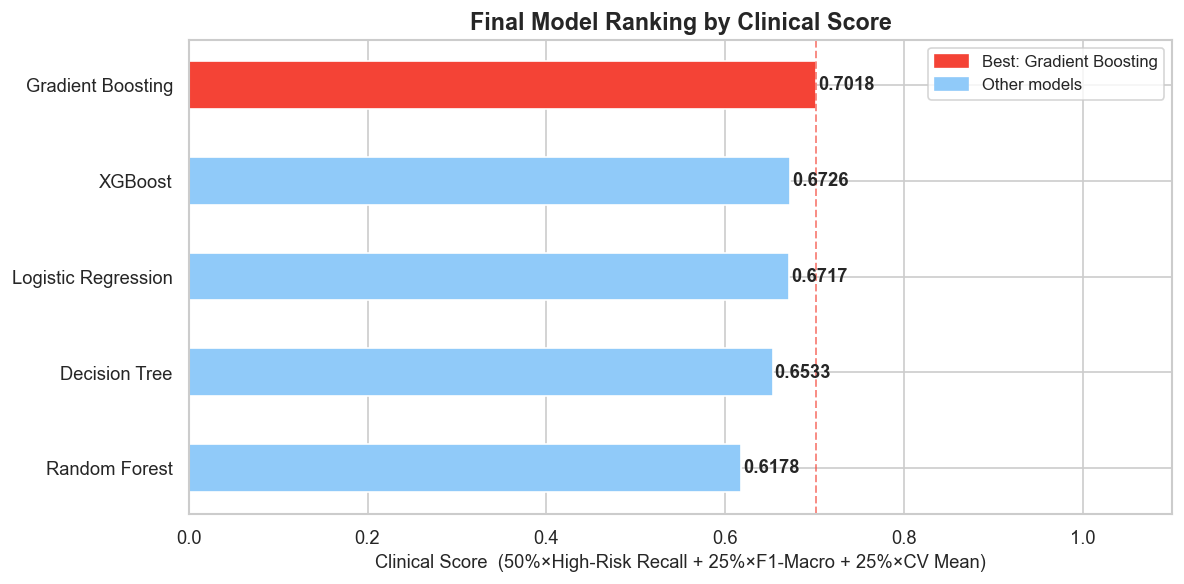

In [16]:
# Final Clinical Score Ranking
comp = clinical_df['Clinical Score'].sort_values(ascending=True)
colors_comp = ['#F44336' if n == best_name else '#90CAF9' for n in comp.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(comp.index, comp.values, color=colors_comp, edgecolor='white', height=0.5)

for bar, val in zip(bars, comp.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, 1.1)
ax.set_xlabel('Clinical Score  (50%×High-Risk Recall + 25%×F1-Macro + 25%×CV Mean)', fontsize=11)
ax.set_title('Final Model Ranking by Clinical Score', fontsize=14, fontweight='bold')
ax.axvline(x=comp.max(), color='#F44336', linestyle='--', linewidth=1.2, alpha=0.6)

best_patch  = mpatches.Patch(color='#F44336', label=f'Best: {best_name}')
other_patch = mpatches.Patch(color='#90CAF9', label='Other models')
ax.legend(handles=[best_patch, other_patch], fontsize=10)

plt.tight_layout()
plt.savefig('08_final_ranking.png', bbox_inches='tight')
plt.show()

---
## 7. Quick Sanity Check: Predict on a Sample Patient

In [17]:
sample_patient = pd.DataFrame([{
    'age':                      67,
    'sex_encoded':              1,     # male
    'smoking':                  1.0,   # yes
    'packs_per_day':            1.5,
    'smoking_years':            30.0,
    'chicha':                   0.0,
    'chicha_years':             0.0,
    'drugs':                    0.0,
    'alcohol_encoded':          0,     # never
    'socio_encoded':            0,     # low
    'work_encoded':             1,     # retired
    'lives_alone':              1.0,
    'has_caregiver':            0.0,
    'chronic_conditions_count': 1,
    'acute_conditions_count':   0,
    'medications_count':        3,
    'allergies_count':          0,
    'surgeries_count':          1,
    'hospitalizations_count':   2,
    'is_covid_vaccinated':      0.0,
}])[FEATURES]

pred_label = best_model.predict(sample_patient)[0]
proba      = best_model.predict_proba(sample_patient)[0]
proba_map  = dict(zip(best_model.classes_, proba))

print('=== Sample Patient Prediction ===')
print(f'  Model      : {best_name}')
print(f'  Risk Level : {pred_label.upper()}')
print(f'  Confidence : {max(proba):.1%}')
print('  Class probabilities:')
for cls, p in sorted(proba_map.items()):
    bar = '█' * int(p * 30)
    print(f'    {cls:8s}: {bar:30s} {p:.1%}')

=== Sample Patient Prediction ===
  Model      : Gradient Boosting
  Risk Level : MEDIUM
  Confidence : 59.4%
  Class probabilities:
    high    : ████████████                   40.4%
    low     :                                0.2%
    medium  : █████████████████              59.4%


this patient is close to the boundary between medium and high risk. The model predicts medium, but the high-risk probability is still large at 40.4%.

This is not necessarily a contradiction, since the patient has several risk factors, but according to the scoring rules, they may not be enough to cross the high-risk threshold. 

For a real emergency system, this borderline result should be shown with caution, such as “medium risk with elevated high-risk probability.”

In [18]:
from pathlib import Path
import json
import joblib

ARTIFACT_DIR = Path(r"C:\Users\may\StudioProjects\emergency_health_record_app\ml-api\artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# 1) Save the trained model
joblib.dump(best_model, ARTIFACT_DIR / "gradient_boosting_risk_model.joblib", compress=3)

# 2) Save the exact feature order
FEATURES = [
    'age',
    'sex_encoded',
    'smoking',
    'packs_per_day',
    'smoking_years',
    'chicha',
    'chicha_years',
    'drugs',
    'alcohol_encoded',
    'socio_encoded',
    'work_encoded',
    'lives_alone',
    'has_caregiver',
    'chronic_conditions_count',
    'acute_conditions_count',
    'medications_count',
    'allergies_count',
    'surgeries_count',
    'hospitalizations_count',
    'is_covid_vaccinated',
]

# 3) Save preprocessing metadata
metadata = {
    "feature_order": FEATURES,
    "alcohol_map": {"never": 0, "rarely": 1, "monthly": 2, "weekly": 3, "daily": 4},
    "socio_map": {"low": 0, "middle": 1, "high": 2, "unknown": 1},
    "work_map": {"employed": 3, "student": 2, "retired": 1, "unemployed": 0},
    "class_names": ["high", "low", "medium"],
}

with open(ARTIFACT_DIR / "risk_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model + metadata")

Saved model + metadata to artifacts/
